In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

from scipy.linalg import solve
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

In [2]:
# DATOS DEL PROBLEMA
##############################################################################

def f(x):
    """
    Lado derecho de la ecuación.

    Elegimos la misma función del ejemplo del profesor.
    """

    return (2*np.pi)**2*np.sin(2*np.pi*x)


def u_exacta(x, alfa, beta):
    """
    Solución exacta correspondiente a f.

    Verificación:
    u'' = f
    u(0)=alfa
    u(1)=beta
    """

    return (
        -np.sin(2*np.pi*x)
        + (beta-alfa)*x
        + alfa
    )

In [3]:
# PARAMETROS
##############################################################################

alfa = 1.5
beta = -0.5

# cantidad de nodos interiores
m = 100

In [4]:
# GRILLA
##############################################################################

h = 1.0/(m+1)

x = np.linspace(0, 1, m+2)

In [5]:
# MATRIZ DENSA
##############################################################################

A = (
    np.diag(-2*np.ones(m))
    + np.diag(np.ones(m-1), 1)
    + np.diag(np.ones(m-1), -1)
)/(h*h)

In [6]:
# MATRIZ ESPARZA
##############################################################################

Asp = diags(
    [
        np.ones(m-1),
        -2*np.ones(m),
        np.ones(m-1)
    ],
    [-1,0,1]
)/(h*h)

In [7]:
# VECTOR b
##############################################################################

b = f(x[1:-1])

# corrección por condiciones de borde
b[0] -= alfa/(h*h)
b[-1] -= beta/(h*h)

In [8]:
# RESOLUCION DENSA
##############################################################################

t0 = time.time()

u_aux = solve(A,b)

t1 = time.time()

In [9]:
# RESOLUCION ESPARZA
##############################################################################

t0sp = time.time()

u_aux_sp = spsolve(Asp,b)

t1sp = time.time()

C:\Users\Lucas\AppData\Local\Temp\ipykernel_2896\1008298421.py:6: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  u_aux_sp = spsolve(Asp,b)


In [10]:
# RECONSTRUCCION DE LA SOLUCION COMPLETA
##############################################################################

u_num = np.concatenate(([alfa],u_aux,[beta]))

u_num_sp = np.concatenate(([alfa],u_aux_sp,[beta]))


In [11]:
# SOLUCION EXACTA
##############################################################################

u_ex = u_exacta(x, alfa, beta)

In [12]:
# ERRORES
##############################################################################

error_denso = np.max(np.abs(u_num-u_ex))

error_esparzo = np.max(np.abs(u_num_sp-u_ex))

print()
print("RESULTADOS")
print("---------------------------")
print("Error denso   =", error_denso)
print("Error esparzo =", error_esparzo)
print()

print("Tiempo denso   =", t1-t0)
print("Tiempo esparzo =", t1sp-t0sp)


RESULTADOS
---------------------------
Error denso   = 0.0003225278783329788
Error esparzo = 0.0003225278783319605

Tiempo denso   = 0.005002260208129883
Tiempo esparzo = 0.023001432418823242


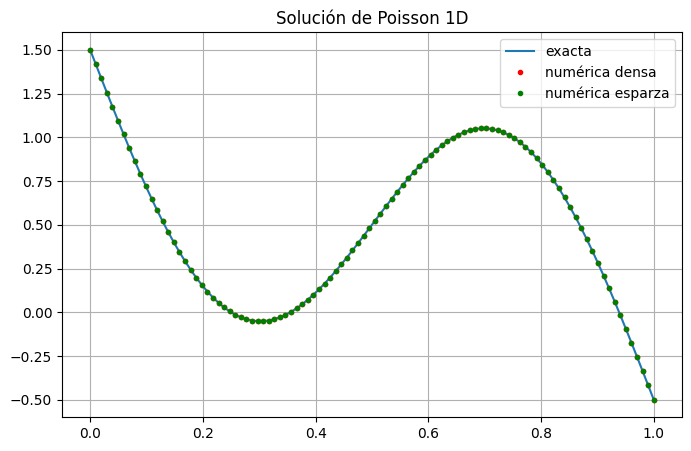

In [13]:
# GRAFICO SOLUCIONES
##############################################################################

plt.figure(figsize=(8,5))

plt.plot(x, u_ex, label="exacta")
plt.plot(x, u_num, 'r.', label="numérica densa")
plt.plot(x, u_num_sp, 'g.', label="numérica esparza")

plt.legend()
plt.grid()

plt.title("Solución de Poisson 1D")

plt.show()

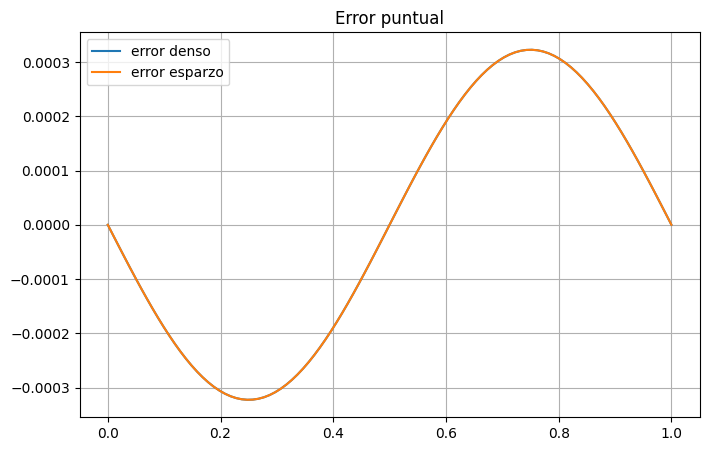

In [14]:
# GRAFICO ERROR
##############################################################################

plt.figure(figsize=(8,5))

plt.plot(x, u_num-u_ex, label="error denso")
plt.plot(x, u_num_sp-u_ex, label="error esparzo")

plt.legend()
plt.grid()

plt.title("Error puntual")

plt.show()